#1. Chuẩn bị thư viện



In [ ]:
!pip install pyspark findspark
import findspark #cho phép tích hợp Spark với các IDE nhu jupyter notebook,VSCode
findspark.init()
#pyspark: API Python chính thức để làm việc với Spark
from pyspark import SparkFiles #Hỗ trợ truy cập các tệp được phân phối tới các worker trong Spark Cluster.
from pyspark.sql import SparkSession #Tạo và cấu hình ứng dụng Spark.
from pyspark.ml.feature import Imputer
from pyspark.ml.feature import VectorAssembler, StandardScaler
#ml.feature: dùng để xử lý và biến đổi dữ liệu trước khi đưa vào mô hình máy học.
  #VectorAssemble: Tập hợp nhiều cột thành một cột vector đặc trưng (feature vector).
  #StandardScaler: Chuẩn hóa dữ liệu (mean = 0, variance = 1)
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
#Đánh giá chất lượng phân cụm, So sánh và chọn số lượng cụm tối ưu
import matplotlib.pyplot as plt
# Vẽ biểu đồ
import pandas as pd
#Thao tác với bảng

spark = SparkSession.builder.appName("Mastering K-means Clustering with PySpark MLlib").getOrCreate()



# 2. Tải tệp dữ liệu



In [ ]:
url = "/content/cust_seg.csv"
spark.sparkContext.addFile(url)

df = spark.read.csv(SparkFiles.get("cust_seg.csv"), header=True, inferSchema=True)
df.show(10)

+---+-----------+---+---+--------------+------+---------+----------+---------+---------------+
|_c0|Customer Id|Age|Edu|Years Employed|Income|Card Debt|Other Debt|Defaulted|DebtIncomeRatio|
+---+-----------+---+---+--------------+------+---------+----------+---------+---------------+
|  0|          1| 41|  2|             6|    19|    0.124|     1.073|        0|            6.3|
|  1|          2| 47|  1|            26|   100|    4.582|     8.218|        0|           12.8|
|  2|          3| 33|  2|            10|    57|    6.111|     5.802|        1|           20.9|
|  3|          4| 29|  2|             4|    19|    0.681|     0.516|        0|            6.3|
|  4|          5| 47|  1|            31|   253|    9.308|     8.908|        0|            7.2|
|  5|          6| 40|  1|            23|    81|    0.998|     7.831|     NULL|           10.9|
|  6|          7| 38|  2|             4|    56|    0.442|     0.454|        0|            1.6|
|  7|          8| 42|  3|             0|    64|   

#3. Tiền xử lý dữ liệu


In [ ]:
# Xử lý giá trị thiếu (NULL)
# Nhận thấy giá trị Defaulted có chứa nhiều giá trị NULL và kết quả hiển thị là 0 và 1. Ta có thể thấy đây là dạng nhị phân
# Gán giá trị default theo điều kiện
from pyspark.sql.functions import col
from pyspark.ml.classification import LogisticRegression
from pyspark.sql import functions as F
from pyspark.sql.utils import AnalysisException


# Kiểm tra giá trị NA trong cột 'default'
df = df.na.drop(subset=["Age", "Edu", "Years Employed", "Income", "Card Debt", "Other Debt", "DebtIncomeRatio"])

# Tách tập dữ liệu có và không có giá trị NA
df_train = df.filter(col("Defaulted").isNotNull())
df_predict = df.filter(col("Defaulted").isNull())

# Chuẩn bị đầu vào cho mô hình
feature_cols = ["Age", "Edu", "Years Employed", "Income", "Card Debt", "Other Debt", "DebtIncomeRatio"]

# Chuyển đổi dữ liệu thành vector đặc trưng
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
df_train = assembler.transform(df_train)

# Chuẩn hóa dữ liệu
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
scaler_model = scaler.fit(df_train)
df_train = scaler_model.transform(df_train)

# Xây dựng mô hình hồi quy logistic
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="Defaulted")
model = lr.fit(df_train)

# Dự đoán các giá trị NA
df_predict = assembler.transform(df_predict)
df_predict = scaler_model.transform(df_predict)
df_predict = model.transform(df_predict)

# Thay thế giá trị dự đoán vào các ô NA
df_predict = df_predict.withColumn("Defaulted", col("prediction").cast("int"))
data_df = df_train.union(df_predict.select(df_train.columns))

#Hiện thị kết quả sau khi xử lí giá trị Null và chuẩn hóa
data_df.show(10)



+---+-----------+---+---+--------------+------+---------+----------+---------+---------------+--------------------+--------------------+
|_c0|Customer Id|Age|Edu|Years Employed|Income|Card Debt|Other Debt|Defaulted|DebtIncomeRatio|            features|      scaledFeatures|
+---+-----------+---+---+--------------+------+---------+----------+---------+---------------+--------------------+--------------------+
|  0|          1| 41|  2|             6|    19|    0.124|     1.073|        0|            6.3|[41.0,2.0,6.0,19....|[5.12670322485211...|
|  1|          2| 47|  1|            26|   100|    4.582|     8.218|        0|           12.8|[47.0,1.0,26.0,10...|[5.87695247726950...|
|  2|          3| 33|  2|            10|    57|    6.111|     5.802|        1|           20.9|[33.0,2.0,10.0,57...|[4.12637088829560...|
|  3|          4| 29|  2|             4|    19|    0.681|     0.516|        0|            6.3|[29.0,2.0,4.0,19....|[3.62620472001735...|
|  4|          5| 47|  1|            31| 

# 4. Chọn số cụm tối ưu

1.   Huấn luyện mô hình KMeans với nhiều giá trị K (2-9)
2.    Chọn K tối ưu bằng chỉ số Silhouette

*   Gần 1: cụm tách biệt tốt
*   Gần 0: cụm chồng lấn
*   Nhỏ hơn 0: cụm bị phân sai









##### Bước 1: Dùng KMeans để huấn luyện mô hình với nhiều giá trị k (số cụm), ví dụ từ 2 đến 9.


In [ ]:
wssse_values =[] #tạo 1 danh sách có sẵn để lưu

evaluator = ClusteringEvaluator(
    predictionCol='prediction', #chứa kết quả dự đoán
    featuresCol='scaledFeatures', #dữ liệu đầu vào hồi nãy
    metricName='silhouette', # tiêu chí đánh giá
    distanceMeasure='squaredEuclidean') #khoảng cách Euclid

for i in range(2,10):
    KMeans_mod = KMeans(featuresCol='scaledFeatures', k=i)
    #Tạo một mô hình K-means với số cụm k=i.
    KMeans_fit = KMeans_mod.fit(data_df)
    output = KMeans_fit.transform(data_df)
    #Phân cụm dữ liệu và trả về DataFrame mới chứa cột prediction
    # (số cụm được gán cho mỗi dòng)
    score = evaluator.evaluate(output)
    #tính  Silhouette Score
    wssse_values.append(score)
    #Lưu điểm số vào danh sách để có thể dùng sau
    # (ví dụ: vẽ biểu đồ chọn k tối ưu)
    print("Silhouette Score:",score)

Silhouette Score: 0.5892571538642232
Silhouette Score: 0.2824764810279524
Silhouette Score: 0.30771922457612044
Silhouette Score: 0.3093193622292749
Silhouette Score: 0.3325424860447971
Silhouette Score: 0.3269618754322402
Silhouette Score: 0.33059526848911197
Silhouette Score: 0.2792989207806122


##### Bước 2: Chọn K tối ưu bằng chỉ số Silhouette và Elbow Method


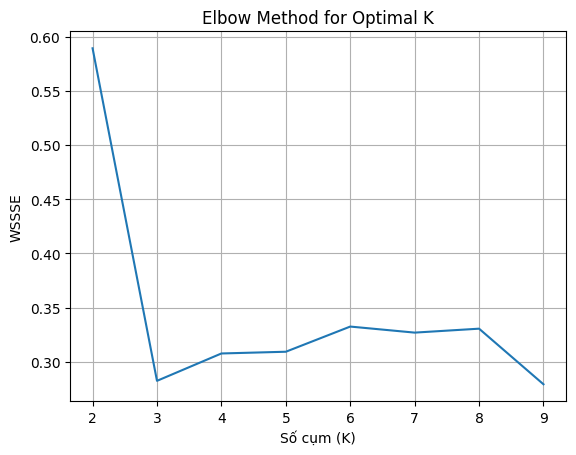

In [ ]:
# Vẽ đồ thị và kết hợp thêm với phương pháp Elbow Method
plt.plot(range(2, 10), wssse_values)
plt.xlabel('Số cụm (K)')
plt.ylabel('WSSSE')
plt.title('Elbow Method for Optimal K')
plt.grid()
plt.show()

##### Bước 3: Nhận xét




  Với Silhouette Score
- Chọn Silhouette Score cao nhất k=2

####=>   Cụm đơn giản, dễ hiểu, phân biệt rõ

---
Với Elbow Method
-  Chọn nơi WSSSE gãy mạnh (k=3) hoặc (k=4)

####=>   Mô hình chi tiết hơn, chấp nhận chồng lấn nhẹ
---
Dựa trên dữ liệu gốc và mục tiêu phân tích ta lựa chọn k=4 là hợp lý nhất vì:
- Cần phân tích 3 hoặc 4 để việc phân chia nhóm dữ liệu chi tiết hơn.
- Với k= 4 vẫn giữ được cấu trúc tương đối tách biệt (Silhouette 0.3 vẫn ổn và lớn hơn khi k =3, điều đó thấy rằng với k=4 thì gần 1 hơn nên tách biệt tốt hơn).




##### Bước 4: Phân cụm với k= 4

In [ ]:
# 1. Khởi tạo mô hình KMeans với K = 4
kmeans = KMeans(k=4, featuresCol="scaledFeatures", predictionCol="cluster")

# 2. Huấn luyện mô hình trên dữ liệu đã chuẩn hóa
kmeans_model = kmeans.fit(data_df)

# 3. Gắn nhãn cụm vào từng dòng dữ liệu
clustered_data = kmeans_model.transform(data_df)
# 4. Tính WSSE
output = KMeans_fit.transform(data_df)
wssse = evaluator.evaluate(output)
print(f"Within Set Sum of Squared Errors (WSSSE) = {wssse}")

Within Set Sum of Squared Errors (WSSSE) = 0.2792989207806122


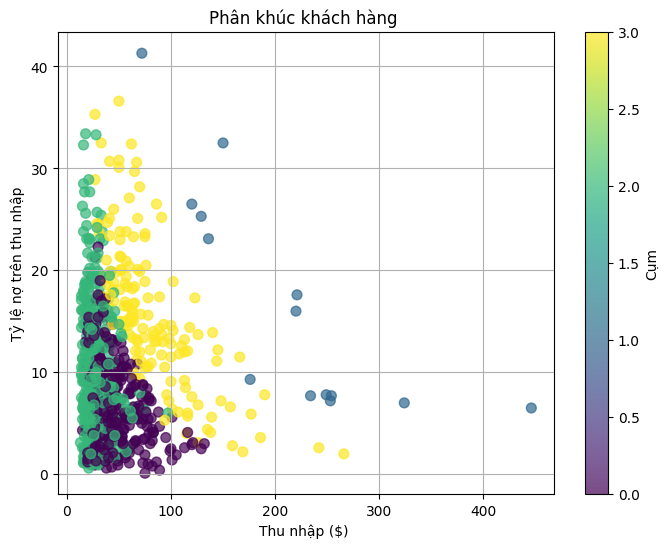

In [ ]:
# Chuyển về Pandas DataFrame
clustered_data_pd = clustered_data.toPandas()

# Trực quan hóa: Chọn 2 cột dễ hiểu để vẽ scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(clustered_data_pd["Income"], clustered_data_pd["DebtIncomeRatio"],
            c=clustered_data_pd["cluster"], cmap='viridis', s=50, alpha=0.7)

plt.xlabel("Thu nhập ($) ")
plt.ylabel("Tỷ lệ nợ trên thu nhập")
plt.title("Phân khúc khách hàng ")
plt.colorbar(label="Cụm")
plt.grid(True)
plt.show()

# 5. Phân tích đặc điểm từng cụm

In [ ]:
# Nhóm theo cụm và tính trung bình
cluster_summary = clustered_data_pd.groupby("cluster")[["Income", "DebtIncomeRatio", "Card Debt", "Other Debt"]].mean()
print(cluster_summary)


             Income  DebtIncomeRatio  Card Debt  Other Debt
cluster                                                    
0         46.407285         6.937086   1.003156    1.934146
1        213.142857        16.821429  11.737786   16.239857
2         27.120104        10.240731   0.879159    1.816256
3         81.377483        15.849007   3.551636    7.350073


# 6. Trực quan hóa


## Lượng khách hàng theo cụm

<ipython-input-78-5af2e9640400>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster', data=clustered_data_pd, palette='Set2')


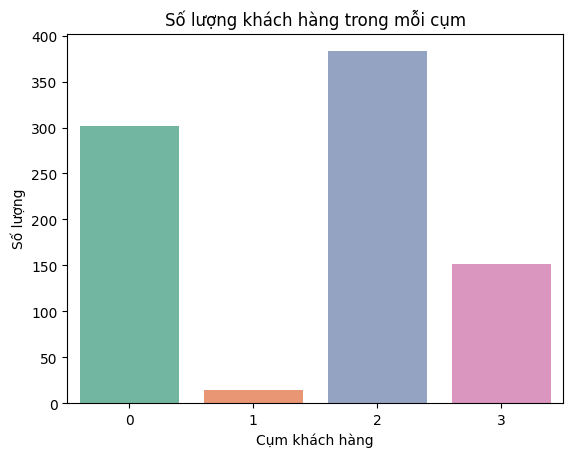

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Đếm số lượng khách hàng trong từng cụm
sns.countplot(x='cluster', data=clustered_data_pd, palette='Set2')
plt.title("Số lượng khách hàng trong mỗi cụm")
plt.xlabel("Cụm khách hàng")
plt.ylabel("Số lượng")
plt.show()

## Phân bố tuổi khách hàng theo cụm

<ipython-input-79-8208e735e7e3>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Age', data=clustered_data_pd, palette='Set1')


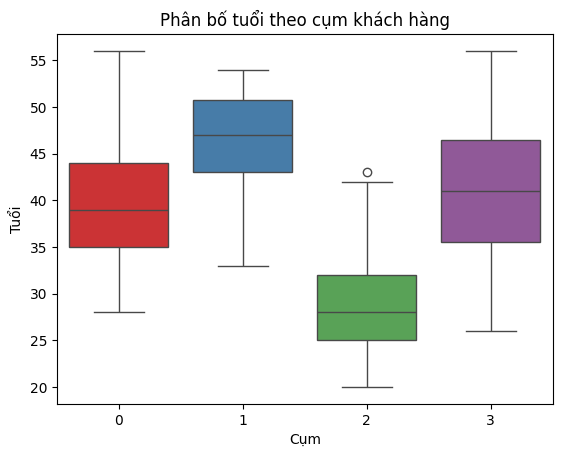

In [ ]:
sns.boxplot(x='cluster', y='Age', data=clustered_data_pd, palette='Set1')
plt.title("Phân bố tuổi theo cụm khách hàng")
plt.xlabel("Cụm")
plt.ylabel("Tuổi")
plt.show()


## Phân tích số năm làm việc của mỗi cụm



<ipython-input-80-46735dd6e08c>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cluster', y='Years Employed', data=clustered_data_pd, palette='Pastel1')


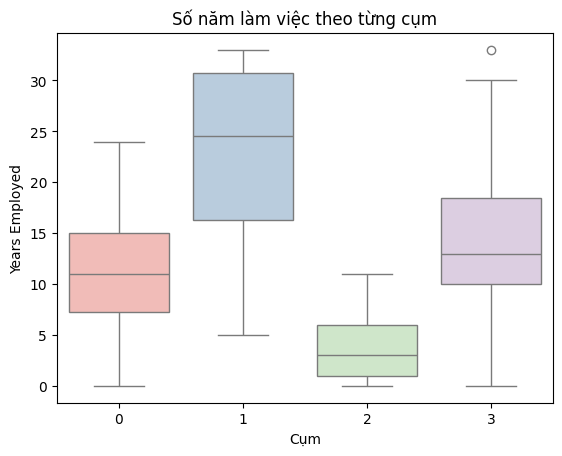

In [ ]:
sns.boxplot(x='cluster', y='Years Employed', data=clustered_data_pd, palette='Pastel1')
plt.title("Số năm làm việc theo từng cụm")
plt.xlabel("Cụm")
plt.ylabel("Years Employed")
plt.show()

## Phân tích trình độ học vấn mỗi cụm


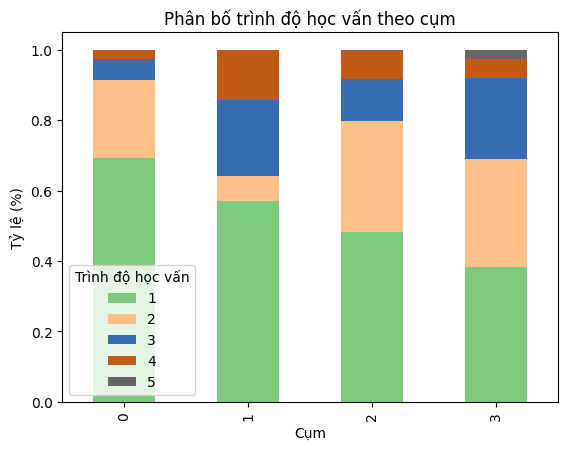

In [ ]:
import pandas as pd

edu_distribution = clustered_data_pd.groupby(['cluster', 'Edu']).size().unstack().fillna(0)
edu_distribution_pct = edu_distribution.div(edu_distribution.sum(axis=1), axis=0)

edu_distribution_pct.plot(kind='bar', stacked=True, colormap='Accent')
plt.title("Phân bố trình độ học vấn theo cụm")
plt.xlabel("Cụm")
plt.ylabel("Tỷ lệ (%)")
plt.legend(title="Trình độ học vấn")
plt.show()

## Phân tích cụm có tình trạng vỡ nợ cao nhất để đánh giá rủi ro tín dụng.




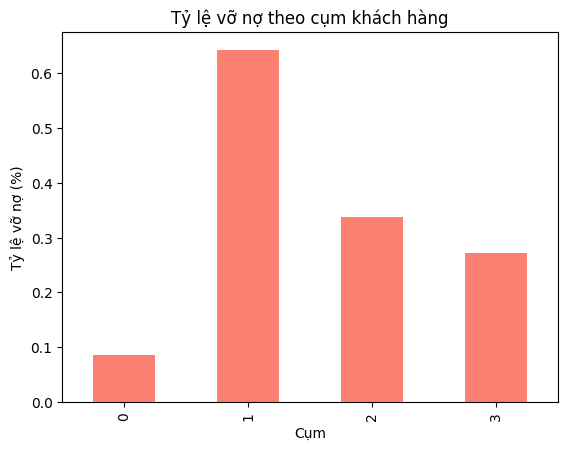

In [ ]:
default_rate = clustered_data_pd.groupby('cluster')['Defaulted'].mean()
default_rate.plot(kind='bar', color='salmon')
plt.title("Tỷ lệ vỡ nợ theo cụm khách hàng")
plt.xlabel("Cụm")
plt.ylabel("Tỷ lệ vỡ nợ (%)")
plt.show()